# NuScenes Setup Guide

## 1. Nuscenes v1.0-mini Dataset Download

Use the following command to download the dataset:

```bash
curl --header 'Host: d36yt3mvayqw5m.cloudfront.net' --header 'User-Agent: Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/134.0.0.0 Safari/537.36' --header 'Accept: text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7' --header 'Accept-Language: en-US,en;q=0.9,zh-CN;q=0.8,zh;q=0.7' --header 'Referer: https://www.nuscenes.org/' 'https://d36yt3mvayqw5m.cloudfront.net/public/v1.0/v1.0-mini.tgz' -L -o 'v1.0-mini.tgz'
```

After downloading, unzip the file:

```bash
tar -xvzf v1.0-mini.tgz
```

---

## 2. Nuscenes Package Installation

Install the nuscenes-devkit package using pip:

```bash
pip install nuscenes-devkit
```

You can find the official repo here: [nuscenes-devkit](https://github.com/nutonomy/nuscenes-devkit)

---

## 3. Nuscenes Map Expansion (For Visualization)

Download the map expansion file:

```bash
curl --header 'Host: d36yt3mvayqw5m.cloudfront.net' --header 'User-Agent: Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/134.0.0.0 Safari/537.36' --header 'Accept: text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7' --header 'Accept-Language: en-US,en;q=0.9,zh-CN;q=0.8,zh;q=0.7' --header 'Referer: https://www.nuscenes.org/' 'https://d36yt3mvayqw5m.cloudfront.net/public/v1.0/nuScenes-map-expansion-v1.3.zip' -L -o 'nuScenes-map-expansion-v1.3.zip'
```

Unzip the file:

```bash
unzip nuScenes-map-expansion-v1.3.zip
```

Then copy the `/expansion` folder and paste it to your data directory in step 1:

You will have `YOUR_DATA_ROOT/nuscenes/maps/expansion/...`

---


\* If you find the dataset is incomplete, please check official download page: [link](https://www.nuscenes.org/nuscenes#download)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from nuscenes.map_expansion.map_api import NuScenesMap
from nuscenes.map_expansion import arcline_path_utils
from nuscenes.map_expansion.bitmap import BitMap
from nuscenes.nuscenes import NuScenes
from pyquaternion import Quaternion
from collections import defaultdict, OrderedDict


In [2]:
import os

# Initialize nuScenes dataset
dataroot = os.path.expanduser('~/Desktop/Nuscenes/nuscenes')
nusc = NuScenes(version='v1.0-mini', dataroot=dataroot, verbose=True)

# Select a scene
scene = nusc.scene[3]
first_sample_token = scene['first_sample_token']
sample = nusc.get('sample', first_sample_token)
ego_vehicle_start_time = sample['timestamp']

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.173 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.


In [3]:
scene['description']

'Parking lot, parked cars, jaywalker, bendy bus, gardening vehicles'

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.186 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.


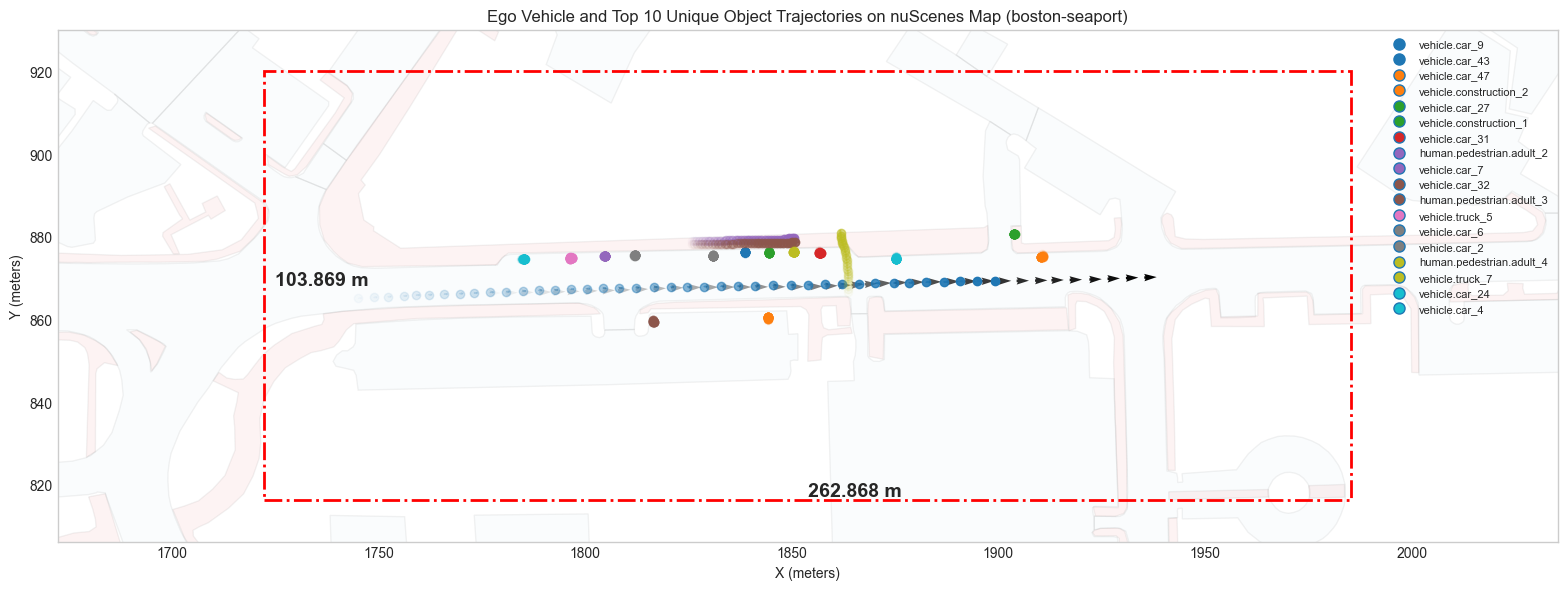

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from nuscenes.nuscenes import NuScenes
from pyquaternion import Quaternion
from collections import defaultdict, OrderedDict
from nuscenes.map_expansion.map_api import NuScenesMap

# Initialize nuScenes dataset
nusc = NuScenes(version='v1.0-mini', dataroot='/Users/liliu/Desktop/Nuscenes/nuscenes', verbose=True)

# Select a scene (second scene)
scene = nusc.scene[3]
first_sample_token = scene['first_sample_token']

# Get the correct map for the scene
log = nusc.get("log", scene["log_token"])
location = log["location"]
nusc_map = NuScenesMap(dataroot='/Users/liliu/Desktop/Nuscenes/nuscenes', map_name=location)

# Store ego trajectory and object trajectories
ego_trajectory = []
ego_orientations = []
timestamps = []

object_trajectories = defaultdict(list)
object_orientations = defaultdict(list)
object_labels = {}

# Function to convert quaternion to 2D yaw angle
def quaternion_to_yaw(quaternion):
    q = Quaternion(quaternion)
    yaw = np.arctan2(2.0 * (q.w * q.z + q.x * q.y), 1.0 - 2.0 * (q.y * q.y + q.z * q.z))
    return yaw

# Track object instances separately
object_name_counter = defaultdict(int)

# Loop through all samples in the scene
sample_token = first_sample_token
while sample_token:
    sample = nusc.get('sample', sample_token)

    # Get timestamp (normalize between 0 and 1 for transparency)
    timestamps.append(sample['timestamp'])

    # Get ego_pose information
    sample_data = nusc.get('sample_data', sample['data']['LIDAR_TOP'])  # Using LiDAR for reference
    ego_pose = nusc.get('ego_pose', sample_data['ego_pose_token'])
    ego_position = tuple(ego_pose['translation'][:2])  # X, Y position
    ego_yaw = quaternion_to_yaw(ego_pose['rotation'])  # Get orientation (yaw)

    ego_trajectory.append(ego_position)
    ego_orientations.append(ego_yaw)

    # Track all objects in the scene
    for ann_token in sample['anns']:
        ann_data = nusc.get('sample_annotation', ann_token)
        instance_token = ann_data['instance_token']
        object_position = tuple(ann_data['translation'][:2])  # Convert to tuple for uniqueness
        object_yaw = quaternion_to_yaw(ann_data['rotation'])  # Get orientation (yaw)

        # Get object category name
        category_name = ann_data['category_name']
        
        # Differentiate identical objects with numbering (_1, _2, ...)
        if instance_token not in object_labels:
            object_name_counter[category_name] += 1
            unique_name = f"{category_name}_{object_name_counter[category_name]}"
            object_labels[instance_token] = unique_name

        # Store object trajectory and orientation
        object_trajectories[instance_token].append(object_position)
        object_orientations[instance_token].append(object_yaw)

    # Move to the next sample
    sample_token = sample['next']

# Normalize timestamps for transparency (0 = oldest, 1 = newest)
timestamps = np.array(timestamps)
timestamps = (timestamps - timestamps.min()) / (timestamps.max() - timestamps.min())  # Normalize between 0 and 1

# Convert ego trajectory to NumPy arrays for plotting
ego_trajectory = np.array(ego_trajectory)
ego_orientations = np.array(ego_orientations)

# **Count unique locations per object (at ranking stage)**
unique_location_counts = {}
filtered_trajectories = {}
filtered_orientations = {}

for instance_token, trajectory in object_trajectories.items():
    unique_locs = OrderedDict()  # Ensure order and store first occurrence of each location
    for i, loc in enumerate(trajectory):
        if loc not in unique_locs:
            unique_locs[loc] = object_orientations[instance_token][i]  # Store first orientation for each unique loc
    
    unique_location_counts[instance_token] = len(unique_locs)  # Count unique locations
    filtered_trajectories[instance_token] = list(unique_locs.keys())  # Store unique locations
    filtered_orientations[instance_token] = list(unique_locs.values())  # Store linked orientations

# **Sort and filter the top 10 longest unique-location trajectories (including ties)**
sorted_lengths = sorted(set(unique_location_counts.values()), reverse=True)  # Get unique lengths, sorted descending

# Keep all objects with trajectory length in the top 10 unique values
if len(sorted_lengths) > 10:
    threshold_length = sorted_lengths[9]  # Get the 10th longest unique length
    selected_instances = {k for k, v in unique_location_counts.items() if v >= threshold_length}
else:
    selected_instances = set(unique_location_counts.keys())  # If fewer than 10 unique lengths, plot all

# Generate distinct colors for selected instances
color_map = cm.get_cmap("tab10", len(selected_instances))
instance_colors = {inst: color_map(i) for i, inst in enumerate(selected_instances)}

# Determine the bounding box for the map (x_min, y_min, x_max, y_max)
x_min, y_min = np.min(ego_trajectory, axis=0) - 50  # Expand by 50m buffer
x_max, y_max = np.max(ego_trajectory, axis=0) + 50  # Expand by 50m buffer
map_bounds = (x_min, y_min, x_max, y_max)

# Define the layer names to be rendered
layer_names = ['drivable_area', 'walkway']

# Render the map patch with 50% transparency
fig, ax = nusc_map.render_map_patch(map_bounds, layer_names, alpha=0.05)

# **Ensure the same distance scale for x and y**
ax.set_aspect('equal')
# Store legend labels
legend_labels = {}

# Plot only the selected top 10 objects with unique colors
# **Apply transparency correctly to instance trajectories**
for instance_token in selected_instances:
    trajectory = np.array(filtered_trajectories[instance_token])
    orientations = np.array(filtered_orientations[instance_token])
    object_name = object_labels[instance_token]
    obj_color = instance_colors[instance_token]

    legend_labels[object_name] = obj_color[:3]  # Store the object name and color for the legend

    for i in range(len(trajectory)):
        alpha = timestamps[i]  # Ensure timestamps are mapped correctly for transparency
        ax.plot(trajectory[i, 0], trajectory[i, 1], marker='o', color=(*obj_color[:3], alpha))  # Correct transparency
        ax.arrow(trajectory[i, 0], trajectory[i, 1],
                 0.5 * np.cos(orientations[i]), 0.5 * np.sin(orientations[i]),
                 head_width=0.3, head_length=0.3, fc=(*obj_color[:3], alpha), ec=(*obj_color[:3], alpha))

# Plot ego trajectory with transparency
for i in range(len(ego_trajectory)):
    alpha = timestamps[i]
        
    dx = 3 * np.cos(ego_orientations[i])
    dy = 3 * np.sin(ego_orientations[i])
    ax.quiver(ego_trajectory[i, 0], ego_trajectory[i, 1], dx, dy,
                  angles='xy', scale_units='xy', scale=1, color=(0,0,0,alpha))



# Create legend for instances
legend_entries = [plt.Line2D([0], [0], marker='o', markerfacecolor=color, markersize=8, linestyle='None', label=name)
                  for name, color in legend_labels.items()]

# Combine both legends
combined_legend = legend_entries
# Labels and title
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.title(f"Ego Vehicle and Top 10 Unique Object Trajectories on nuScenes Map ({location})")

# Labels and title
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.title(f"Ego Vehicle and Top 10 Unique Object Trajectories on nuScenes Map ({location})")
plt.legend(handles=combined_legend, loc='upper right', fontsize=8)  # Keep both legends
plt.grid()
plt.show()

In [1]:
# %matplotlib ipympl
%matplotlib widget
# %matplotlib notebook

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.410 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.


/opt/anaconda3/envs/nuscenes/lib/python3.9/site-packages/descartes/patch.py:62: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  vertices = concatenate([
/opt/anaconda3/envs/nuscenes/lib/python3.9/site-packages/descartes/patch.py:64: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  [asarray(r)[:, :2] for r in t.interiors])


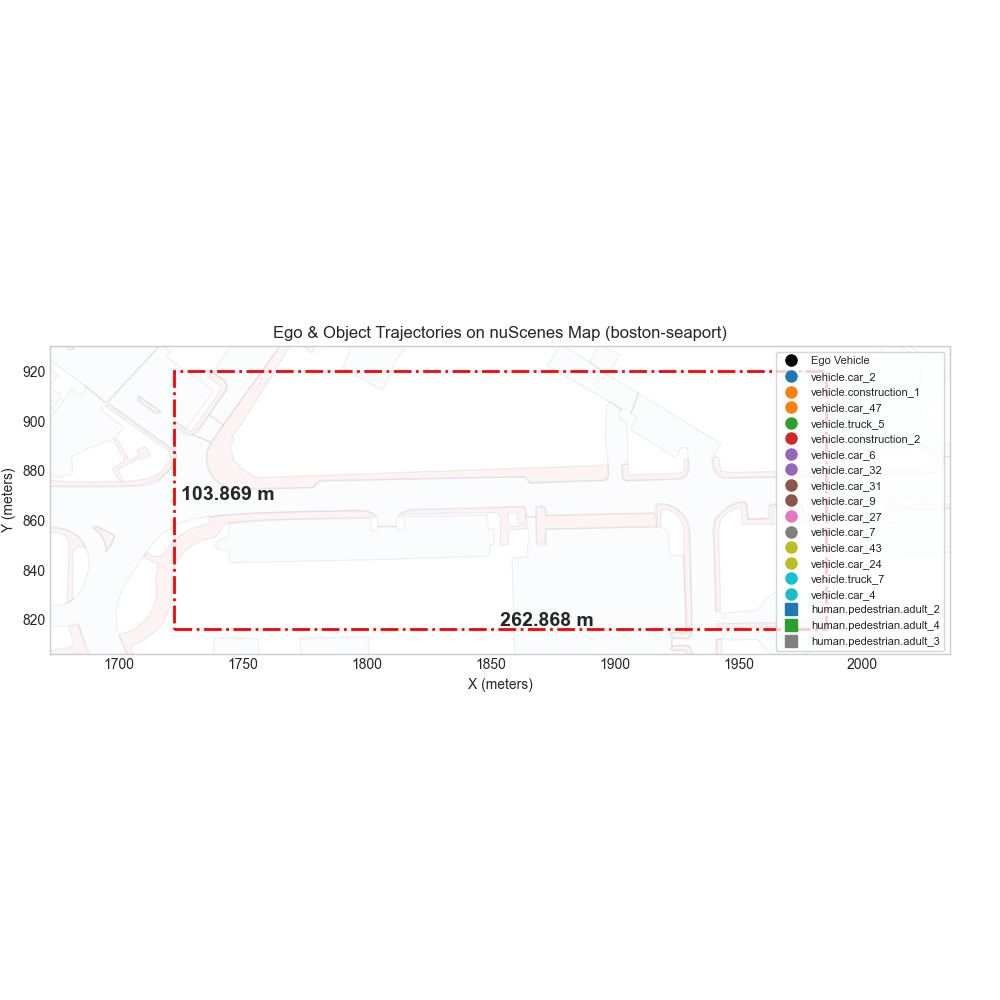

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.animation as animation
from nuscenes.nuscenes import NuScenes
from pyquaternion import Quaternion
from collections import defaultdict, OrderedDict
from nuscenes.map_expansion.map_api import NuScenesMap

# === Dataset setup ===
nusc = NuScenes(version='v1.0-mini', dataroot='/Users/liliu/Desktop/Nuscenes/nuscenes', verbose=True)
scene = nusc.scene[3]
first_sample_token = scene['first_sample_token']
log = nusc.get("log", scene["log_token"])
location = log["location"]
nusc_map = NuScenesMap(dataroot='/Users/liliu/Desktop/Nuscenes/nuscenes', map_name=location)

# === Marker style by category root ===
category_marker_map = {
    'vehicle': 'o',
    'human': 's',
    'movable_object': '^',
    'animal': 'D',
    'static_object': 'x',
    'flat': 'P'
}

# === Containers ===
ego_trajectory, ego_orientations, timestamps = [], [], []
object_trajectories, object_orientations = defaultdict(list), defaultdict(list)
object_labels = {}
object_name_counter = defaultdict(int)
object_category_root = {}

def quaternion_to_yaw(q):
    q = Quaternion(q)
    return np.arctan2(2.0 * (q.w * q.z + q.x * q.y), 1.0 - 2.0 * (q.y**2 + q.z**2))

# === Loop through frames ===
sample_token = first_sample_token
while sample_token:
    sample = nusc.get('sample', sample_token)
    timestamps.append(sample['timestamp'])

    ego_pose = nusc.get('ego_pose', nusc.get('sample_data', sample['data']['LIDAR_TOP'])['ego_pose_token'])
    ego_trajectory.append(tuple(ego_pose['translation'][:2]))
    ego_orientations.append(quaternion_to_yaw(ego_pose['rotation']))

    for ann_token in sample['anns']:
        ann = nusc.get('sample_annotation', ann_token)
        inst = ann['instance_token']
        category = ann['category_name']
        root = category.split('.')[0]
        object_category_root[inst] = root

        if inst not in object_labels:
            object_name_counter[category] += 1
            object_labels[inst] = f"{category}_{object_name_counter[category]}"

        object_trajectories[inst].append(tuple(ann['translation'][:2]))
        object_orientations[inst].append(quaternion_to_yaw(ann['rotation']))
    sample_token = sample['next']

# === Normalize & Filter ===
timestamps = np.array(timestamps)
ego_trajectory = np.array(ego_trajectory)
ego_orientations = np.array(ego_orientations)

unique_location_counts = {
    k: len(set(object_trajectories[k])) for k in object_trajectories
}
sorted_lens = sorted(set(unique_location_counts.values()), reverse=True)
threshold = sorted_lens[9] if len(sorted_lens) > 10 else 0
selected_instances = {k for k, v in unique_location_counts.items() if v >= threshold}

# === Color map ===
color_map = cm.get_cmap("tab10", len(selected_instances))
instance_colors = {inst: color_map(i) for i, inst in enumerate(selected_instances)}

# === Set up map plot ===
x_min, y_min = ego_trajectory.min(axis=0) - 50
x_max, y_max = ego_trajectory.max(axis=0) + 50
fig, ax = nusc_map.render_map_patch((x_min, y_min, x_max, y_max), ['drivable_area', 'walkway'], alpha=0.05)
fig.set_size_inches(10, 10)
ax.set_aspect('equal')

# Set tight bounding box for the Axes object (not just subplots)
ax.set_position([0.05, 0.05, 0.9, 0.9])  # [left, bottom, width, height] in figure coords

# === Ego ===
ego_dot, = ax.plot([], [], 'o', color='black', markersize=6)
ego_arrow = ax.quiver([], [], [], [], angles='xy', scale_units='xy', scale=1, color='black')

# === Object dots & legend entries ===
obj_dots = {}
grouped_legend = defaultdict(list)

for i, inst in enumerate(selected_instances):
    category = object_category_root[inst]
    marker = category_marker_map.get(category, 'o')
    color = instance_colors[inst]
    label = object_labels[inst]
    
    dot, = ax.plot([], [], marker=marker, linestyle='None', color=color, markersize=6)
    obj_dots[inst] = dot

    legend_entry = plt.Line2D([0], [0], marker=marker, color=color, linestyle='None', markersize=8, label=label)
    grouped_legend[category].append(legend_entry)

# === Animation functions ===
def init():
    ego_dot.set_data([], [])
    ego_arrow.set_offsets([0, 0])
    ego_arrow.set_UVC(0, 0)
    for dot in obj_dots.values():
        dot.set_data([], [])
    return [ego_dot, ego_arrow] + list(obj_dots.values())

def update(frame):
    x, y = ego_trajectory[frame]
    yaw = ego_orientations[frame]
    ego_dot.set_data(x, y)
    ego_arrow.set_offsets([x, y])
    ego_arrow.set_UVC(3 * np.cos(yaw), 3 * np.sin(yaw))
    for inst in selected_instances:
        traj = object_trajectories[inst]
        if frame < len(traj):
            px, py = traj[frame]
            obj_dots[inst].set_data(px, py)
    return [ego_dot, ego_arrow] + list(obj_dots.values())

ani = animation.FuncAnimation(fig, update, init_func=init,
                              frames=len(timestamps), interval=300, blit=False)

# === Grouped Legend ===
category_order = ['vehicle', 'movable_object', 'human', 'animal', 'static_object', 'flat']
legend_entries = [plt.Line2D([0], [0], marker='o', color='black', linestyle='None', markersize=8, label='Ego Vehicle')]

for cat in category_order:
    if cat in grouped_legend:
        legend_entries.extend(grouped_legend[cat])

ax.legend(handles=legend_entries, loc='upper right', fontsize=8, frameon=True)
plt.title(f"Ego & Object Trajectories on nuScenes Map ({location})")
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.grid()
plt.show()

In [17]:
ani.save("./nuscenes_animation.gif", writer='pillow', fps=5)

In [ ]:
# %matplotlib ipympl
%matplotlib widget
# %matplotlib notebook

/opt/anaconda3/envs/nuscenes/lib/python3.9/site-packages/matplotlib/animation.py:887: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you have outputted the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


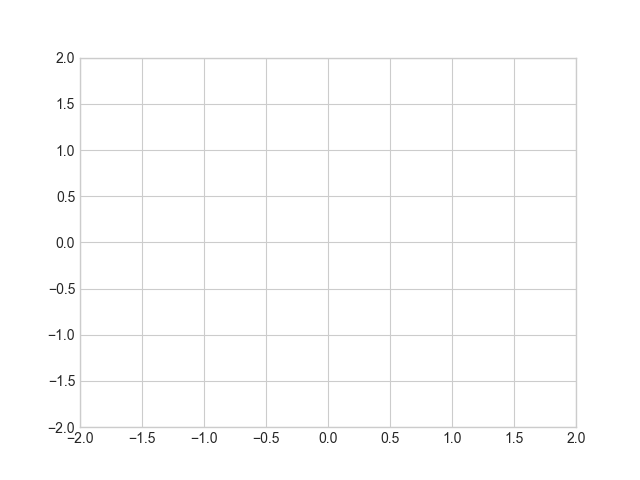

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Create figure and axis
fig, ax = plt.subplots()
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
point, = ax.plot([], [], 'ro')  # red dot

# Initialization function
def init():
    point.set_data([], [])
    return point,

# Update function for each frame
def update(frame):
    angle = 2 * np.pi * frame / 100
    x = np.cos(angle)
    y = np.sin(angle)
    point.set_data(x, y)
    return point,

# Animate
ani = FuncAnimation(fig, update, frames=100, init_func=init, interval=100, blit=True)

# Show animation
# plt.show()

In [22]:
instance_id = "0b570b8baa5243be821ec380d153de92"
print_debug = False